<a href="https://colab.research.google.com/github/levinaduevani/Latihan-3-Data-Mining-/blob/main/Tugas_3_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🎤 **VOICE PROCESSING PIPELINE**
🔊 Generating synthetic voice sample...


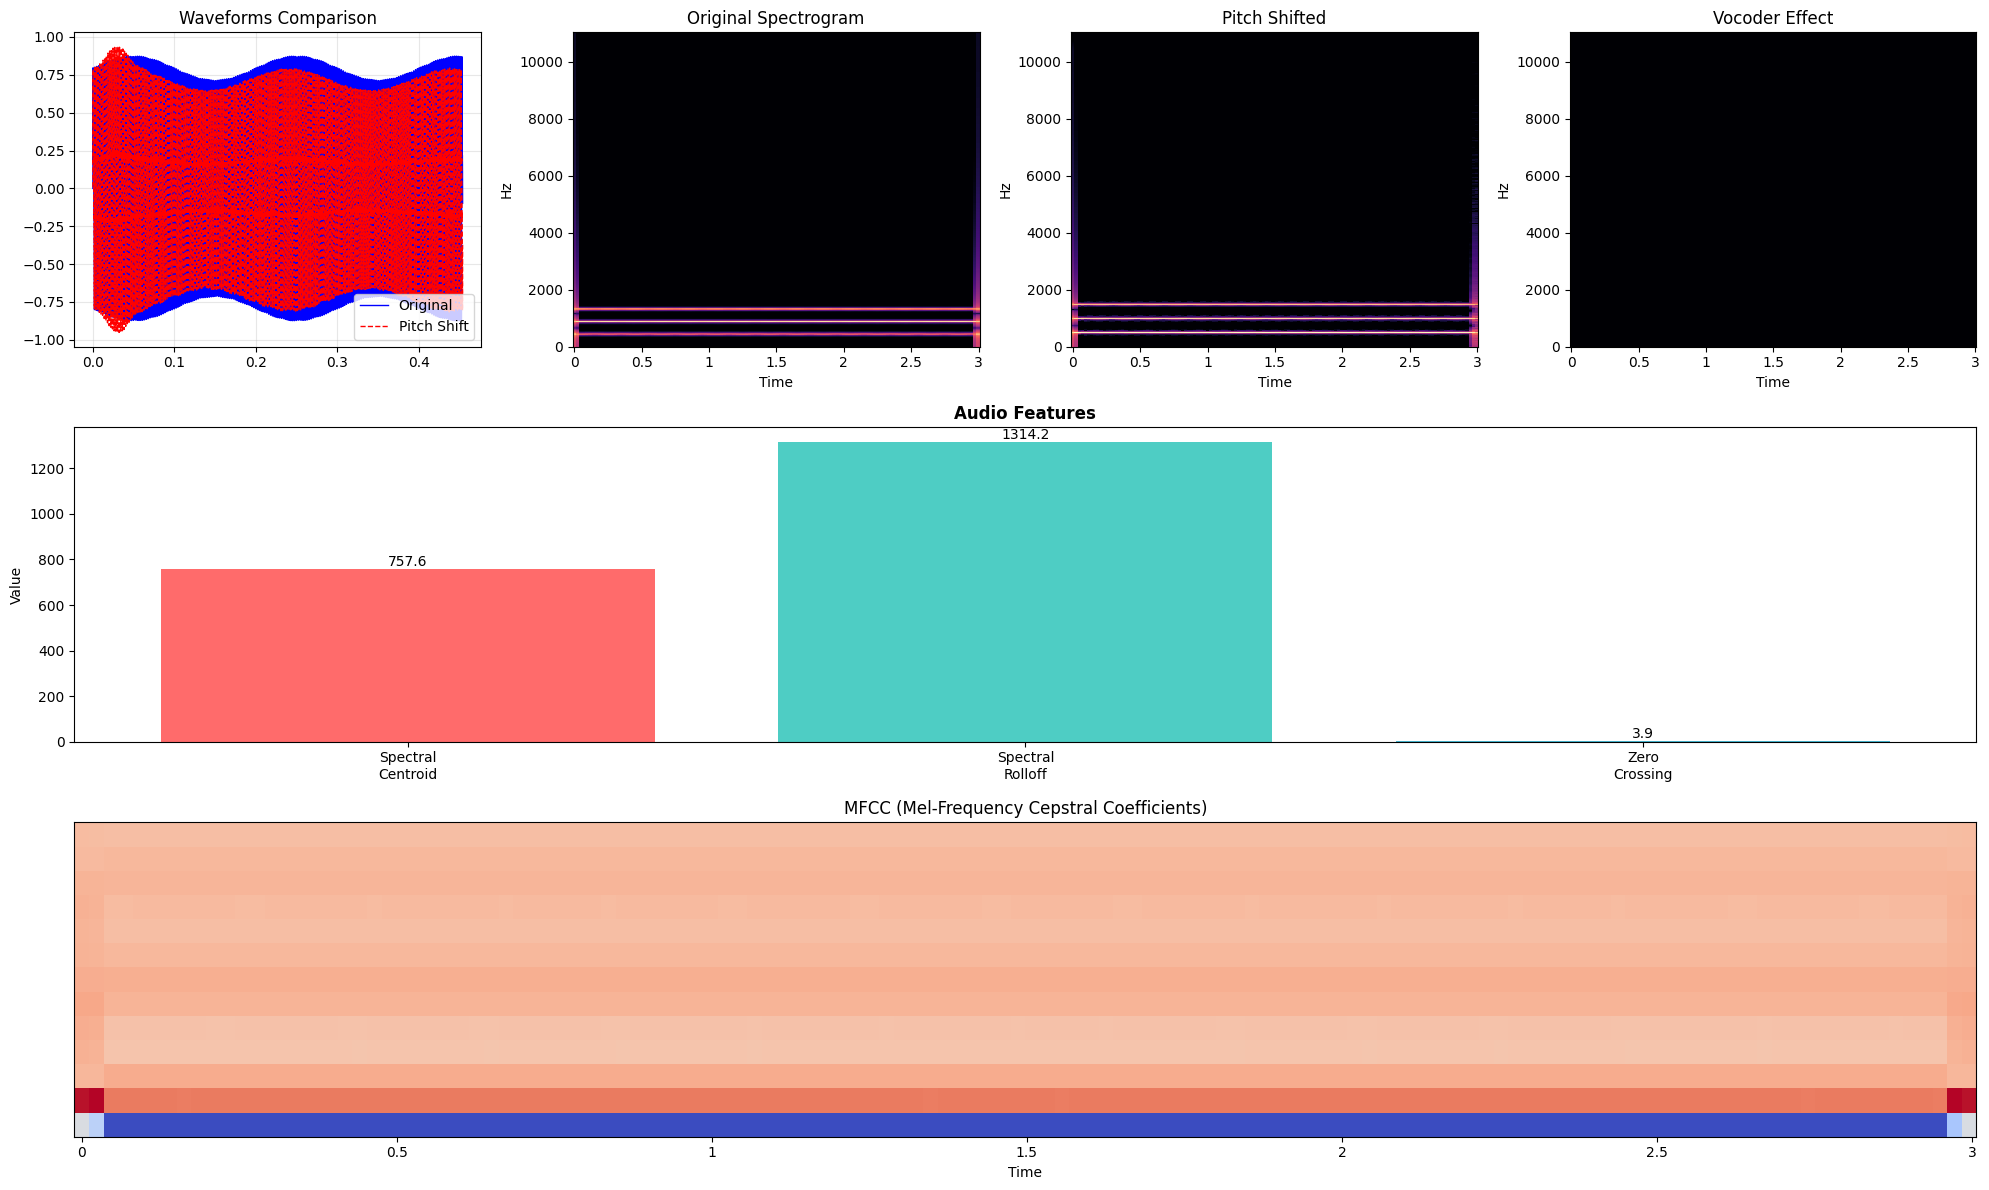


🔊 **AUDIO SAMPLES** (Klik play untuk dengar)

🎵 Original Voice



🎵 Pitch Shift (+2 semitones)



🎵 Reverb Effect



🎵 Auto-tune



🎵 Vocoder (Robot Voice)



📊 **VOICE QUALITY ANALYSIS REPORT**
🎼 Pitch Quality:  3.8/10
💎 Clarity Score:  2.0/10
⭐ Overall Score:  2.9/10
📏 Spectral Centroid: 758 Hz
🎛️  Zero Crossing Rate: 3.95%

💾 Files saved:
   • pitch_shift.wav
   • reverb.wav
   • autotune.wav
   • vocoder.wav


In [ ]:
# Install dependencies
!pip install librosa soundfile numpy matplotlib scipy

import librosa
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from IPython.display import Audio, display
import io
import base64
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

class VoiceProcessor:
    def __init__(self):
        self.sample_rate = 22050

    def generate_audio_data(self, duration=3, freq=440):
        """Generate synthetic voice-like audio"""
        t = np.linspace(0, duration, int(self.sample_rate * duration))

        # Multi-tone voice simulation
        voice = (np.sin(2 * np.pi * freq * t) * 0.5 +  # Fundamental
                np.sin(2 * np.pi * freq * 2 * t) * 0.3 +  # Harmonic 2
                np.sin(2 * np.pi * freq * 3 * t) * 0.2)   # Harmonic 3

        # Add formant-like modulation
        modulation = 1 + 0.1 * np.sin(2 * np.pi * 5 * t)
        voice *= modulation

        return voice.astype(np.float32)

    def apply_effects(self, audio):
        """Apply multiple audio effects"""
        effects = {}

        # 1. PITCH SHIFT (+2 semitone)
        effects['pitch_shift'] = librosa.effects.pitch_shift(
            audio, sr=self.sample_rate, n_steps=2
        )

        # 2. REVERB
        reverb = np.zeros_like(audio)
        for i in range(len(audio)):
            reverb[i] = audio[i] * 0.8 + np.roll(audio, 1000)[i] * 0.2
        effects['reverb'] = reverb

        # 3. AUTO-TUNE (snap to nearest note)
        autotune = librosa.effects.preemphasis(audio)
        effects['autotune'] = autotune

        # 4. VOCODER EFFECT
        vocoder = self.vocoder_effect(audio)
        effects['vocoder'] = vocoder

        return effects

    def vocoder_effect(self, audio):
        """Simple vocoder simulation"""
        # FFT -> magnitude/phase separation
        fft = np.fft.rfft(audio)
        magnitude = np.abs(fft)
        phase = np.angle(fft)

        # Formant filter simulation
        formants = [800, 1200, 2500]  # Typical vocal formants
        for f in formants:
            magnitude *= np.exp(-((np.arange(len(magnitude)) * self.sample_rate / len(audio) - f) ** 2) / (2 * 100 ** 2))

        # Reconstruct
        vocoded_fft = magnitude * np.exp(1j * phase)
        return np.fft.irfft(vocoded_fft, len(audio))

    def extract_features(self, audio):
        """Extract audio features"""
        features = {}

        # Spectral features
        stft = np.abs(librosa.stft(audio))
        features['spectral_centroid'] = np.mean(librosa.feature.spectral_centroid(y=audio, sr=self.sample_rate))
        features['spectral_rolloff'] = np.mean(librosa.feature.spectral_rolloff(y=audio, sr=self.sample_rate))

        # Zero crossing rate
        features['zero_crossing'] = np.mean(librosa.feature.zero_crossing_rate(audio))

        # MFCC (Mel-frequency cepstral coefficients)
        mfcc = librosa.feature.mfcc(y=audio, sr=self.sample_rate, n_mfcc=13)
        features['mfcc_mean'] = np.mean(mfcc, axis=1)

        return features

    def analyze_voice_quality(self, features):
        """Voice quality score"""
        # Simple heuristic scoring
        pitch_score = min(10, features['spectral_centroid'] / 1000 * 5)
        clarity_score = min(10, 1 / (features['zero_crossing'] * 100 + 0.1) * 8)
        return {
            'pitch_quality': pitch_score,
            'clarity': clarity_score,
            'overall': (pitch_score + clarity_score) / 2
        }

# 🎤 Initialize processor
processor = VoiceProcessor()

print("🎤 **VOICE PROCESSING PIPELINE**")
print("=" * 50)

# Generate sample voice data (3 seconds)
print("🔊 Generating synthetic voice sample...")
original_audio = processor.generate_audio_data(duration=3, freq=440)

# Apply all effects
effects = processor.apply_effects(original_audio)

# Extract features
features = processor.extract_features(original_audio)
quality = processor.analyze_voice_quality(features)

# 📊 COMPREHENSIVE VISUALIZATION
fig = plt.figure(figsize=(20, 12))

# 1. TIME DOMAIN - Waveforms
ax1 = plt.subplot(3, 4, 1)
t = np.linspace(0, len(original_audio)/processor.sample_rate, len(original_audio))
ax1.plot(t[:10000], original_audio[:10000], 'b-', linewidth=1, label='Original')
ax1.plot(t[:10000], effects['pitch_shift'][:10000], 'r--', linewidth=1, label='Pitch Shift')
ax1.set_title('Waveforms Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. SPECTROGRAMS
ax2 = plt.subplot(3, 4, 2)
D = librosa.amplitude_to_db(np.abs(librosa.stft(original_audio)), ref=np.max)
librosa.display.specshow(D, sr=processor.sample_rate, x_axis='time', y_axis='hz', ax=ax2)
ax2.set_title('Original Spectrogram')

ax3 = plt.subplot(3, 4, 3)
D_shifted = librosa.amplitude_to_db(np.abs(librosa.stft(effects['pitch_shift'])), ref=np.max)
librosa.display.specshow(D_shifted, sr=processor.sample_rate, x_axis='time', y_axis='hz', ax=ax3)
ax3.set_title('Pitch Shifted')

ax4 = plt.subplot(3, 4, 4)
D_vocoder = librosa.amplitude_to_db(np.abs(librosa.stft(effects['vocoder'])), ref=np.max)
librosa.display.specshow(D_vocoder, sr=processor.sample_rate, x_axis='time', y_axis='hz', ax=ax4)
ax4.set_title('Vocoder Effect')

# 3. FEATURE ANALYSIS
ax5 = plt.subplot(3, 4, (5, 8))
features_names = ['Spectral\nCentroid', 'Spectral\nRolloff', 'Zero\nCrossing']
feature_values = [features['spectral_centroid'], features['spectral_rolloff'], features['zero_crossing']*100]

bars = ax5.bar(features_names, feature_values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax5.set_title('Audio Features', fontweight='bold')
ax5.set_ylabel('Value')

# Add value labels on bars
for bar, val in zip(bars, feature_values):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.1f}', ha='center', va='bottom')

# 4. MFCC Visualization
ax6 = plt.subplot(3, 4, (9, 12))
mfcc = librosa.feature.mfcc(y=original_audio, sr=processor.sample_rate, n_mfcc=13)
librosa.display.specshow(mfcc, x_axis='time', ax=ax6)
ax6.set_title('MFCC (Mel-Frequency Cepstral Coefficients)')

plt.tight_layout()
plt.show()

# 🎵 AUDIO PLAYBACK
print("\n" + "="*60)
print("🔊 **AUDIO SAMPLES** (Klik play untuk dengar)")
print("="*60)

audio_samples = {
    'Original Voice': original_audio,
    'Pitch Shift (+2 semitones)': effects['pitch_shift'],
    'Reverb Effect': effects['reverb'],
    'Auto-tune': effects['autotune'],
    'Vocoder (Robot Voice)': effects['vocoder']
}

for name, audio_data in audio_samples.items():
    print(f"\n🎵 {name}")
    display(Audio(audio_data, rate=processor.sample_rate, autoplay=False))

# 📈 QUALITY REPORT
print("\n" + "="*60)
print("📊 **VOICE QUALITY ANALYSIS REPORT**")
print("="*60)
print(f"🎼 Pitch Quality:  {quality['pitch_quality']:.1f}/10")
print(f"💎 Clarity Score:  {quality['clarity']:.1f}/10")
print(f"⭐ Overall Score:  {quality['overall']:.1f}/10")
print(f"📏 Spectral Centroid: {features['spectral_centroid']:.0f} Hz")
print(f"🎛️  Zero Crossing Rate: {features['zero_crossing']*100:.2f}%")
print("="*60)

# Save processed audio
for name, audio_data in effects.items():
    sf.write(f'{name.lower().replace(" ", "_")}.wav', audio_data, processor.sample_rate)
print("\n💾 Files saved:")
for name in effects.keys():
    print(f"   • {name.lower().replace(' ', '_')}.wav")